In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader
import optuna                               # TODO: implement optuna for hyperparameter optimization

from resources.MLdata import *
from resources.MLfunc import *

# Multilayer Perceptrion (MLP)

## Model

In [3]:
class MLPhlayer(nn.Module):
    def __init__(self, in_size, out_size, norm=None):
        super(MLPhlayer, self).__init__()
        self.norm = norm
        self.fc = nn.Linear(in_size, out_size)
        self.act = nn.ReLU()
        if norm:
            self.normL = nn.LayerNorm(out_size)
    
    def forward(self, x):
        x = self.act(self.fc(x))
        if self.norm:
            x = self.normL(x)
        return x

class MLP(nn.Module):
    def __init__(self, in_size, h_size, out_size, norm=None):
        super(MLP, self).__init__()
        self.norm = norm
        self.fcIN = nn.Linear(in_size, h_size[0])
        self.fcOUT = nn.Linear(h_size[-1], out_size)
        self.act = nn.ReLU()
        if norm:
            self.normIN = nn.LayerNorm(h_size[0])
        self.dropout = nn.Dropout(0.25)
        self.hlayers = nn.ModuleList([
            MLPhlayer(i, j, norm) for i, j in zip(h_size[:-1], h_size[1:])])

    def forward(self, x):
        x = self.act(self.fcIN(x))
        if self.norm:
            x = self.normIN(x)
        for layer in self.hlayers:
            x = layer(x)
        x = self.fcOUT(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


# Stress-Strain Curve Optimization
General approximation from change in node coordinate components to change in stress-strain curve.

In [4]:
DAT = DATA(load=True)

In [5]:
in_size = DAT.train_in.shape[-1]
out_size = DAT.train_out.shape[-1]
h_size = [2**8]*4

BATCH_SIZE = 16
LEARNING_RATE = 9e-4
n_epochs = 5

In [6]:
trainDS = Dataset_(DAT.train_in, DAT.train_outST)
valDS = Dataset_(DAT.val_in, DAT.val_outST)
testDS = Dataset_(DAT.test_in, DAT.test_outST)

train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=valDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=testDS, batch_size=BATCH_SIZE, shuffle=False)

In [7]:
mlp1 = MLP(in_size, h_size, out_size).to(device)
mlp1.apply(weights_init)
# print(torch.cuda.is_available())   ### TODO: GPU

opt = optim.Adam(mlp1.parameters(), lr=LEARNING_RATE)
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=50, min_delta=1e-4, verbose=True)

ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.2427, patience=15, threshold=1e-4, verbose=True)
OneCycleLR = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, steps_per_epoch=len(train_dataloader), epochs=n_epochs)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

In [8]:
mlp1, epoch, train_lossLog, val_lossLog = train_model("mpl", mlp1, lossf, n_epochs, opt, train_dataloader, val_dataloader, scheduler=ReduceLR, earlyStop=earlyStop)

Epoch: 1 - Loss: 0.02660968340933323
Best Epoch: 5, with loss 0.009056134149432182


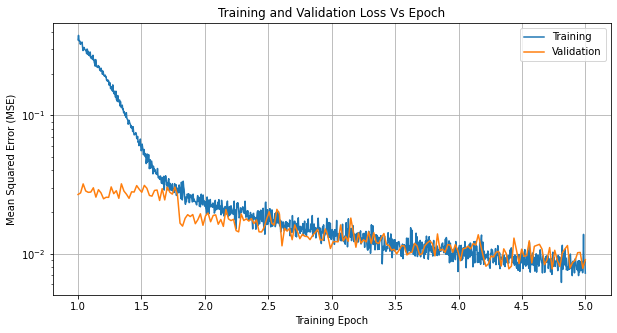

In [9]:
plot_loss(epoch, train_lossLog, val_lossLog)

In [10]:
test_outputs = predict_model("mlp", mlp1, test_dataloader)
test_outputs = standardize(test_outputs, DAT.outParams[0], DAT.outParams[1], mode=1)

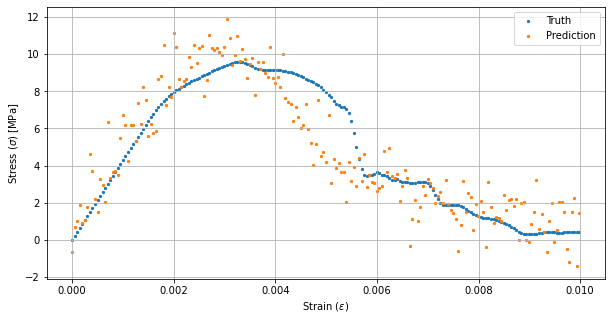

In [11]:
plot_StressStrainOUT(DAT.perOUT, DAT.train_out, test_outputs)

In [12]:
err = list(abs(sum(DAT.test_out[:,60:140] - test_outputs[:,60:140])))
err.index(min(err)), err.index(max(err))

(46, 35)

# Distribution Function Optimization
Unique function approximations from perfect lattice coorindates to each disorder ($\Delta$) distribution.

### Version 1
$[x_i, y_i] \to \delta x_i$  
$[x_i, y_i] \to \delta y_i$

In [13]:
DAT1 = DATA(load=True, DisDist=1)

In [14]:
DAT1.train_in1.shape, DAT1.dx_out1.shape

((357, 2), (3588, 357, 1))

In [15]:
in_size = DAT1.train_in1.shape[-1]
out_size = DAT1.dx_out1.shape[-1]
h_size = [10, 100, 100, 10]

BATCH_SIZE = 1
LEARNING_RATE = 1e-3
n_epochs = 10

In [16]:
trainDS1x = Dataset_(DAT1.train_in1, DAT1.dx_out1[0])
trainDS1y = Dataset_(DAT1.train_in1, DAT1.dy_out1[0])

train1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=True)
train1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=True)

test1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=False)
test1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=False)

In [17]:
mlp2 = MLP(in_size, h_size, out_size).to(device)
mlp2.apply(weights_init)

opt = optim.Adam(mlp2.parameters(), lr=LEARNING_RATE)
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=50, min_delta=1e-4, verbose=True)

ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.2427, patience=10, threshold=1e-4, verbose=True)
OneCycleLR = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, steps_per_epoch=len(train1x_dataloader), epochs=n_epochs)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

In [18]:
mlp2, epoch, train_lossLog, val_lossLog = train_model("mlp", mlp2, lossf, n_epochs, opt, train1x_dataloader, test1x_dataloader, scheduler=ReduceLR, earlyStop=earlyStop)

Epoch: 1 - Loss: 1.980350375175476
Epoch: 10 - Loss: 1.9618701934814453
Best Epoch: 9, with loss 1.9596401453018188


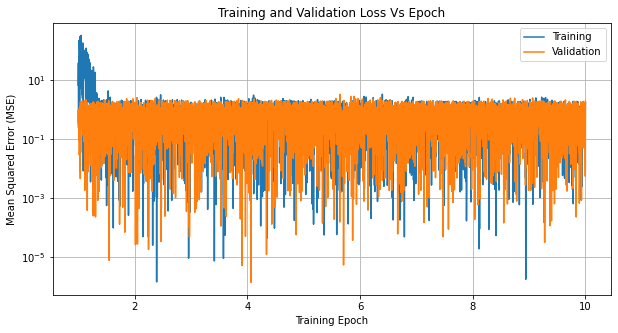

In [19]:
plot_loss(epoch, train_lossLog, val_lossLog)

In [20]:
test_outputs = predict_model("mlp", mlp2, test1x_dataloader)
max(test_outputs[:,0] - DAT1.dx_out1[0,:,0]), min(test_outputs[:,0] - DAT1.dx_out1[0,:,0])

(1.4683872219276424, -1.4142361495650349)

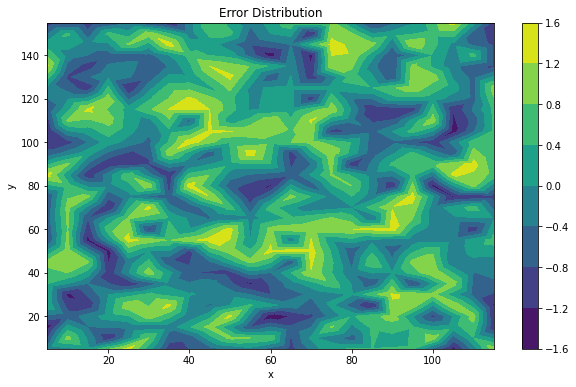

In [21]:
plot_Distribution(DAT1.train_in1, test_outputs[:,0], dx_out1=DAT1.dx_out1[0,:,0], typ="contour")

### Version 2
$[x_1, y_2, ..., x_n, y_n] \to [\delta x_i, ..., \delta x_n]$  
$[x_1, y_2, ..., x_n, y_n] \to [\delta y_i, ..., \delta y_n]$


In [22]:
DAT2 = DATA(load=True, DisDist=2)

In [23]:
DAT2.train_in2.shape, DAT2.dx_out2.shape

((2, 714), (3588, 2, 357))

In [24]:
in_size = DAT2.train_in2.shape[-1]
out_size = DAT2.dx_out2.shape[-1]
h_size = [2**10]

BATCH_SIZE = 8
LEARNING_RATE = 9e-4
n_epochs = 10000

In [25]:
trainDS1x = Dataset_(DAT2.train_in2, DAT2.dx_out2[0])
trainDS1y = Dataset_(DAT2.train_in2, DAT2.dy_out2[0])

train1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=True)
train1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=True)

test1x_dataloader = DataLoader(dataset=trainDS1x, batch_size=BATCH_SIZE, shuffle=False)
test1y_dataloader = DataLoader(dataset=trainDS1y, batch_size=BATCH_SIZE, shuffle=False)

In [26]:
mlp3 = MLP(in_size, h_size, out_size).to(device)
mlp3.apply(weights_init)

opt = optim.Adam(mlp3.parameters(), lr=LEARNING_RATE)
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=100, min_delta=1e-11, verbose=True)

ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.2427, patience=16, threshold=1e-4, verbose=True)
OneCycleLR = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, steps_per_epoch=len(train1x_dataloader), epochs=n_epochs)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

In [27]:
mlp3, epoch, train_lossLog, val_lossLog = train_model("mlp", mlp3, lossf, n_epochs, opt, train1x_dataloader, test1x_dataloader, scheduler=ReduceLR, earlyStop=earlyStop)

Epoch: 1 - Loss: 3406.274169921875
Epoch: 10 - Loss: 1184.90869140625
Epoch: 20 - Loss: 323.61669921875
Epoch: 30 - Loss: 84.35993957519531
Epoch: 40 - Loss: 19.45762825012207
Epoch: 50 - Loss: 13.609375953674316
Epoch: 60 - Loss: 7.131889820098877
Epoch: 70 - Loss: 2.248600482940674
Epoch: 80 - Loss: 1.4456208944320679
Epoch: 90 - Loss: 0.47719427943229675
Epoch: 100 - Loss: 0.33955851197242737
Epoch: 110 - Loss: 0.14317117631435394
Epoch: 120 - Loss: 0.057592108845710754
Epoch: 130 - Loss: 0.0404014065861702
Epoch: 140 - Loss: 0.03098168969154358
Epoch: 150 - Loss: 0.021439963951706886
Epoch: 160 - Loss: 0.009497929364442825
Epoch: 170 - Loss: 0.007659318391233683
Epoch: 180 - Loss: 0.006600383203476667
Epoch: 190 - Loss: 0.003981929738074541
Epoch: 200 - Loss: 0.007429564371705055
Epoch: 210 - Loss: 0.008201026357710361
Epoch 00213: reducing learning rate of group 0 to 9.7080e-06.
Epoch: 220 - Loss: 0.0021132344845682383
Epoch: 230 - Loss: 0.0009145352523773909
Epoch: 240 - Loss: 0.

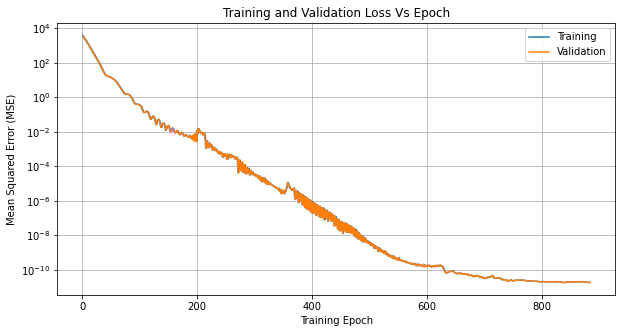

In [28]:
plot_loss(epoch, train_lossLog, val_lossLog)

In [29]:
test_outputs = predict_model("mlp", mlp3, test1x_dataloader)
max(abs(test_outputs[0] - DAT2.dx_out2[0,0])), min(abs(test_outputs[0] - DAT2.dx_out2[0,0]))

(1.251355743647764e-05, 9.179679238968674e-10)

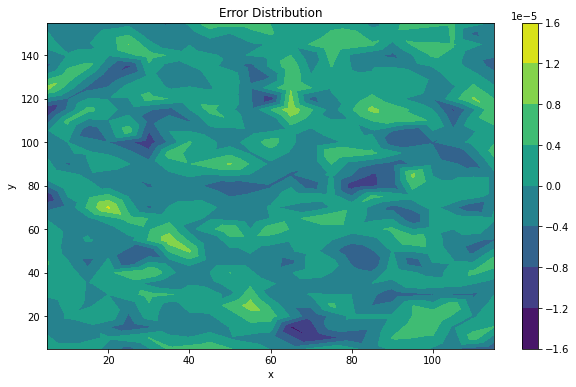

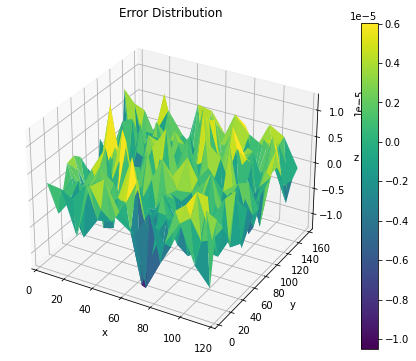

In [30]:
plot_Distribution(DAT2.train_in1, test_outputs[0], dx_out1=DAT2.dx_out2[0,0], typ="both")

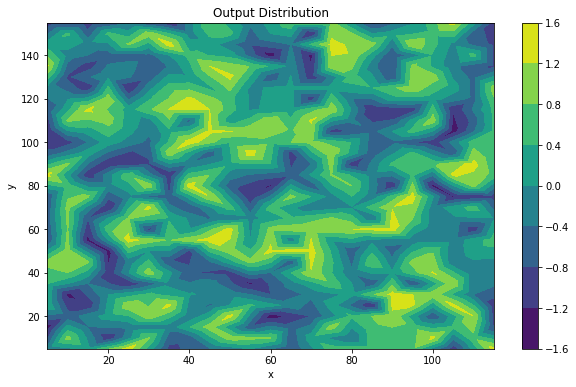

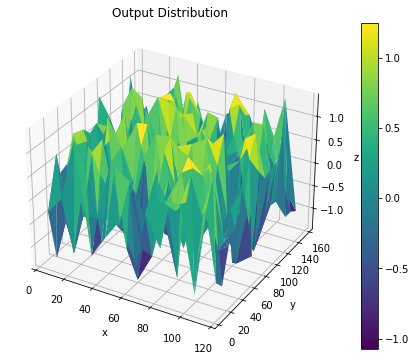

In [31]:
plot_Distribution(DAT2.train_in1, test_outputs[0], typ="both")

In [32]:
for name, param in mlp3.state_dict().items():
    print(f"{name}: {param.shape}\n{param}\n")

fcIN.weight: torch.Size([1024, 714])
tensor([[ 0.0739, -0.0171, -0.0224,  ..., -0.0687,  0.0191, -0.0294],
        [-0.0256, -0.0062, -0.0148,  ..., -0.0398, -0.0391, -0.0049],
        [-0.0514, -0.0056,  0.0320,  ...,  0.0183,  0.0286,  0.0131],
        ...,
        [ 0.0024,  0.0127, -0.0003,  ...,  0.0065, -0.0002, -0.0053],
        [ 0.0385, -0.0273, -0.0797,  ..., -0.0322, -0.0171, -0.0098],
        [ 0.0067, -0.0344,  0.0241,  ...,  0.0120,  0.0571,  0.0393]])

fcIN.bias: torch.Size([1024])
tensor([ 3.8110e-04, -1.3994e-03,  2.8032e-06,  ..., -1.1509e-03,
         0.0000e+00,  5.0675e-05])

fcOUT.weight: torch.Size([357, 1024])
tensor([[-5.3200e-03,  1.5192e-03,  6.3102e-02,  ..., -3.6335e-02,
         -1.8281e-02, -3.5152e-02],
        [ 2.1508e-02, -1.9073e-02, -2.3755e-03,  ...,  9.0962e-05,
          1.2415e-02,  4.1258e-02],
        [ 1.2252e-02, -9.8206e-03, -5.8244e-03,  ...,  9.4606e-03,
         -2.3012e-02, -8.6295e-03],
        ...,
        [ 3.2997e-02,  3.8691e-02,  